In [8]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

from src.configs.defaults import *
from src.configs.train_config import TrainConfig
from src.utils.set_seed import set_seed
from src.data.utils import load_HandBonesDataset, split_train_val, encode_mask_to_rle, decode_rle_to_mask
from src.data.transforms import get_valid_transform, get_test_transform, get_tta_transform
from src.metrics.dice import dice_coef

import json
import numpy as np
import pandas as pd
import cv2
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

In [3]:
cfg = TrainConfig(
    data_root = TRIAN_ROOT,
    saved_root = SAVED_DIR,
    saved_name="upernet_2048_flip_best.pt",
    split_file_root = "random", # SPLIT_FILE_ROOT,
        
    total=False,
    tta=True,
        
    img_size=2048,
    use_scale=True,
    use_rotate=True,
    use_flip=True,
    use_contrast=True,
        
    model_name='upernet',
    encoder_name='resnext50_32x4d',
    loss_type='BDJ',
    scheduler='warmup',
    optimizer='adam',

    batch_size=2,
    num_workers_train=NUM_WORKERS_TRAIN,
    num_workers_val=NUM_WORKERS_VAL,

    lr=LR,
    num_epochs=NUM_EPOCHS,
    val_every=VAL_EVERY,
    num_patience=NUM_PATIENCE,

    seed=RANDOM_SEED,
        
    use_wandb=False,
)

In [4]:
class XRayValidDataset(Dataset):         # valid 시각화를 위한 dataset
    def __init__(self, cfg):
        
        self.image_root = os.path.join(cfg.data_root, "DCM")
        self.label_root = os.path.join(cfg.data_root, "outputs_json")
        
        pngs, jsons = load_HandBonesDataset(self.image_root, self.label_root)
        
        filenames, labelnames = split_train_val(cfg, pngs, jsons, is_train=False)
        
        self.filenames = filenames
        self.labelnames = labelnames
        self.is_train = False
        self.transforms = get_valid_transform(cfg)
        self.tta_transforms = get_tta_transform() if cfg.tta else None
    
    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, item):
        image_name = self.filenames[item]
        image_path = os.path.join(self.image_root, image_name)
        
        image = cv2.imread(image_path)
        image = image / 255.
        
        label_name = self.labelnames[item]
        label_path = os.path.join(self.label_root, label_name)
        
        # (H, W, NC) 모양의 label을 생성합니다.
        label_shape = tuple(image.shape[:2]) + (len(CLASSES), )
        label = np.zeros(label_shape, dtype=np.uint8)
        
        # label 파일을 읽습니다.
        with open(label_path, "r") as f:
            annotations = json.load(f)
        annotations = annotations["annotations"]
        
        # 클래스 별로 처리합니다.
        for ann in annotations:
            c = ann["label"]
            class_ind = CLASS2IND[c]
            points = np.array(ann["points"])
            
            # polygon 포맷을 dense한 mask 포맷으로 바꿉니다.
            class_label = np.zeros(image.shape[:2], dtype=np.uint8)
            cv2.fillPoly(class_label, [points], 1)
            label[..., class_ind] = class_label
        
        if self.transforms is not None:
            inputs = {"image": image, "mask": label} if self.is_train else {"image": image}
            result = self.transforms(**inputs)
            
            image = result["image"]
            label = result["mask"] if self.is_train else label
        
        if self.tta_transforms is not None:
            tta_result = self.tta_transforms(image=image)
            tta_image = tta_result["image"]

            image = np.stack([image, tta_image], axis=0)
            label = np.stack([label, label], axis=0)
        
        if self.tta_transforms is None:
            image = image.transpose(2, 0, 1)
            label = label.transpose(2, 0, 1)
        else:
            image = image.transpose(0, 3, 1, 2)
            label = label.transpose(0, 3, 1, 2)
        
        image = torch.from_numpy(image).float()
        label = torch.from_numpy(label).float()
            
        return image, image_name, label

In [6]:
def validation(model, data_loader, thr=0.5, tta=False):
    model.eval()
    model = model.cuda()
    
    dices = []
    rles = []
    filename_and_class = []
    
    with torch.no_grad():
        n_class = len(CLASSES)
        for step, (images, image_names, masks) in tqdm(enumerate(data_loader), total=len(data_loader)):
            images, masks = images.cuda(), masks.cuda()         
            
            if not tta:
                if images.shape[-2:] != (2048, 2048):
                    outputs = model(images)
                else:
                    with torch.amp.autocast(device_type="cuda"):
                        outputs = model(images)
                        
            else:
                # 원본 데이터 + TTA 데이터 형태
                if images.dim() == 4 and images.size(0) % 2 == 0:
                    batch_size = images.size(0) // 2
                    images = images.view(batch_size, 2, images.size(1), images.size(2), images.size(3))
                    masks = masks.view(batch_size, 2, masks.size(1), masks.size(2), masks.size(3))
                
                batch_size, n_tta, C, H, W = images.shape            
                outputs_tta = []
                
                for t in range(n_tta):
                    img = images[:, t]
                    
                    if img.shape[-2:] != (2048, 2048):
                        output = model(img)
                    else:
                        with torch.amp.autocast(device_type="cuda"):
                            output = model(img)

                    outputs_tta.append(output)
            
                outputs = torch.stack(outputs_tta, dim=1)
                outputs[:, 1] = torch.flip(outputs[:, 1], dims=[-1])
                outputs = torch.mean(outputs, dim=1)
                masks = masks[:, 0]
            
            output_h, output_w = outputs.size(-2), outputs.size(-1)
            mask_h, mask_w = masks.size(-2), masks.size(-1)
            
            if output_h != mask_h or output_w != mask_w:
                outputs = F.interpolate(outputs, size=(mask_h, mask_w), mode="bilinear")
            
            outputs = torch.sigmoid(outputs)
            outputs = (outputs > thr).float()
            
            dice = dice_coef(masks, outputs)
            dices.append(dice) 
            
            outputs = outputs.cpu().numpy()
            
            for output, image_name in zip(outputs, image_names):
                for c, segm in enumerate(output):
                    rle = encode_mask_to_rle(segm)
                    rles.append(rle)
                    filename_and_class.append(f"{IND2CLASS[c]},{image_name}")
                
    dices = torch.cat(dices, 0)
    dices_per_class = torch.mean(dices, 0)
    
    return dices_per_class, rles, filename_and_class

In [7]:
set_seed(cfg.seed)
    
model = torch.load(os.path.join(cfg.saved_root, cfg.saved_name), weights_only=False)

valid_dataset = XRayValidDataset(cfg)

valid_loader = DataLoader(
    dataset=valid_dataset, 
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers_val,
    drop_last=False
)

dices_per_class, rles, filename_and_class = validation(model, valid_loader, tta=cfg.tta)

classes, filename = zip(*[x.split(",") for x in filename_and_class])
image_name = [os.path.basename(f) for f in filename]
df = pd.DataFrame({
    "image_name": image_name,
    "class": classes,
    "rle": rles,
})

  0%|          | 0/80 [00:00<?, ?it/s]

##

/tmp/ipykernel_2571052/2089654023.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dice_df, x='Dice', y='Class', palette='viridis')


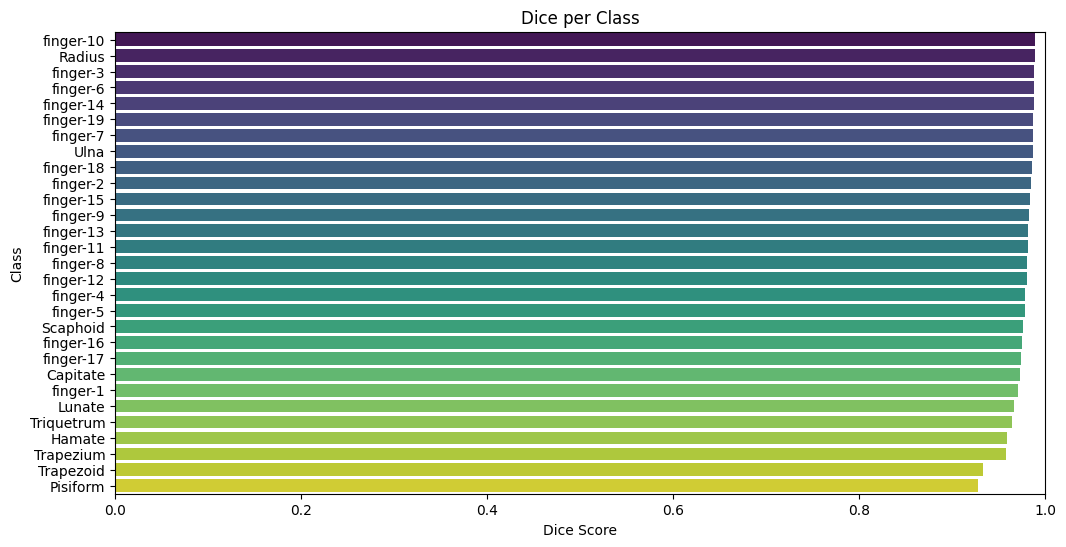

In [10]:
dice_df = pd.DataFrame({
    'Class': CLASSES,
    'Dice': dices_per_class.cpu()
})

dice_df = dice_df.sort_values(by='Dice', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=dice_df, x='Dice', y='Class', palette='viridis')
plt.title('Dice per Class')
plt.xlabel('Dice Score')
plt.ylabel('Class')
plt.xlim(0, 1)
plt.show()

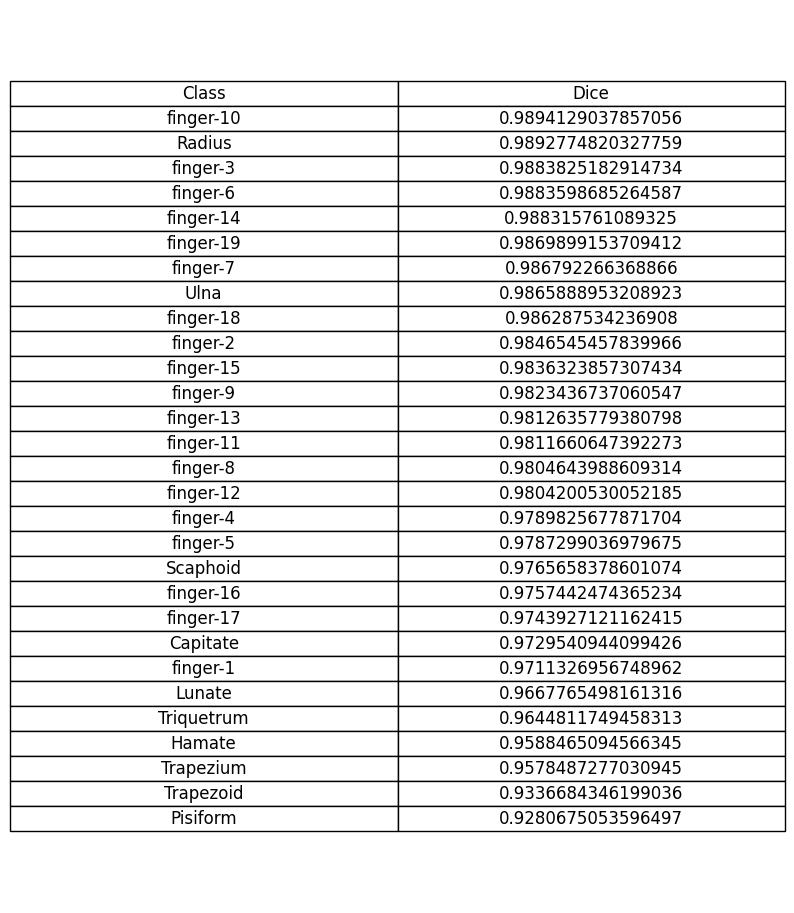

In [ ]:
fig, ax = plt.subplots(figsize=(10, len(CLASSES)*0.4))
ax.axis('off')
table = ax.table(
    cellText=dice_df.values,
    colLabels=dice_df.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)

plt.show()

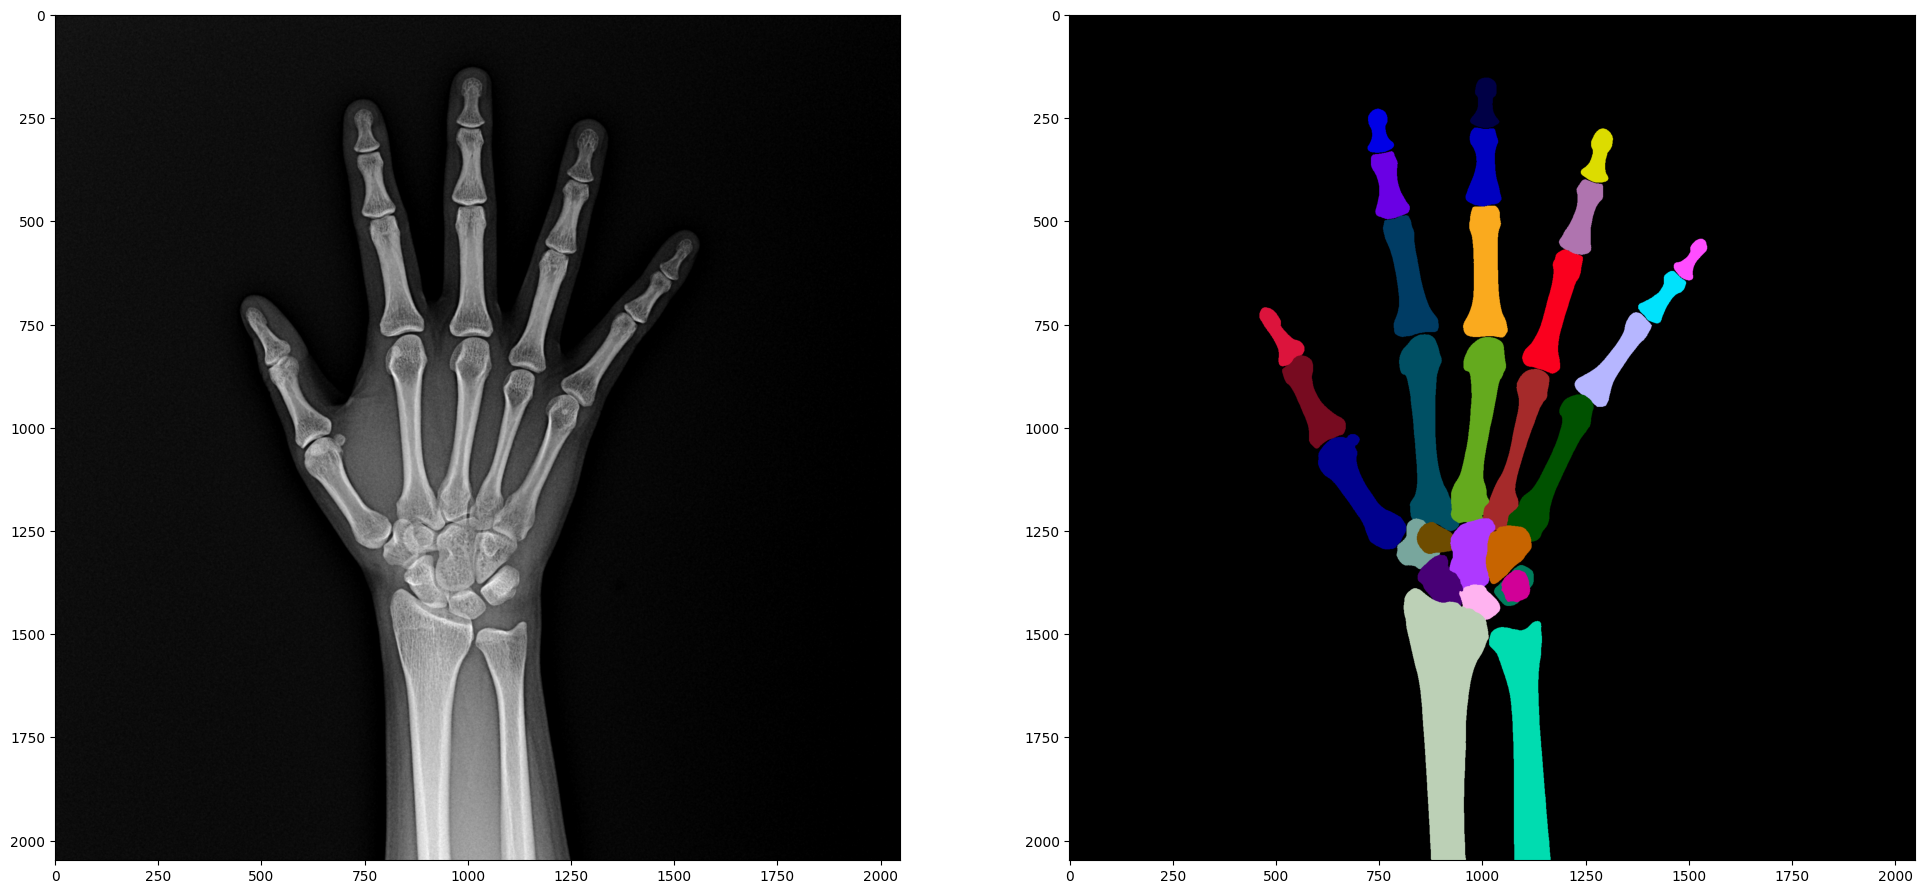

In [ ]:
def label2rgb(label):
    image_size = label.shape[1:] + (3, )
    image = np.zeros(image_size, dtype=np.uint8)
    
    for i, class_label in enumerate(label):
        image[class_label == 1] = PALETTE[i]
        
    return image

def result_visualization(rles, filename_and_class, index):
    image = cv2.imread(os.path.join(os.path.join(cfg.data_root, "DCM"), filename_and_class[index].split(",")[1]))
    
    preds = []
    for rle in rles[:len(CLASSES)]:
        pred = decode_rle_to_mask(rle, height=2048, width=2048)
        preds.append(pred)

    preds = np.stack(preds, 0)
    
    fig, ax = plt.subplots(1, 2, figsize=(24, 12))
    ax[0].imshow(image)
    ax[1].imshow(label2rgb(preds))

    plt.show()
    
result_visualization(rles, filename_and_class, 15)

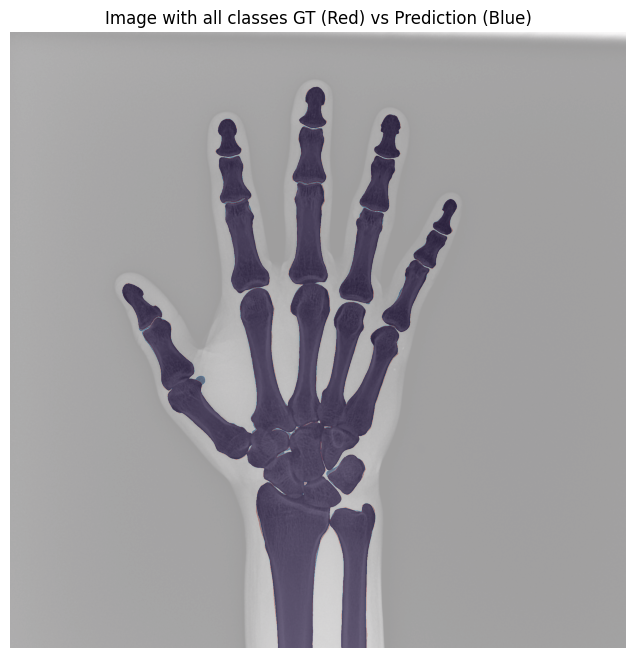

In [20]:
def visualize_all_classes(df, cfg, dataset, image_idx):
    _, image_name, gt_label = dataset[image_idx]
    if cfg.tta:
        gt_label = gt_label[0] 
    
    image_path = os.path.join(os.path.join(cfg.data_root, "DCM"), image_name)
    image_np = cv2.imread(image_path)
    image_np = cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB)
    
    gt_mask_total = np.zeros_like(gt_label[0].numpy())
    pred_mask_total = np.zeros_like(gt_label[0].numpy())
    
    for class_name, class_idx in CLASS2IND.items():
        gt_mask_total = np.maximum(gt_mask_total, gt_label[class_idx].numpy())
        
        rle_row = df[(df['image_name'] == image_name.split('/')[-1]) & (df['class'] == class_name)]
        if len(rle_row) == 0:
            pred_mask = np.zeros_like(gt_mask_total)
        else:
            pred_mask = decode_rle_to_mask(rle_row['rle'].values[0], gt_mask_total.shape[0], gt_mask_total.shape[1])
        pred_mask_total = np.maximum(pred_mask_total, pred_mask)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(image_np)
    plt.imshow(gt_mask_total, cmap='Reds', alpha=0.4)
    plt.imshow(pred_mask_total, cmap='Blues', alpha=0.4)
    plt.title(f'Image with all classes GT (Red) vs Prediction (Blue)')
    plt.axis('off')
    plt.show()

visualize_all_classes(df, cfg, valid_dataset, 40)

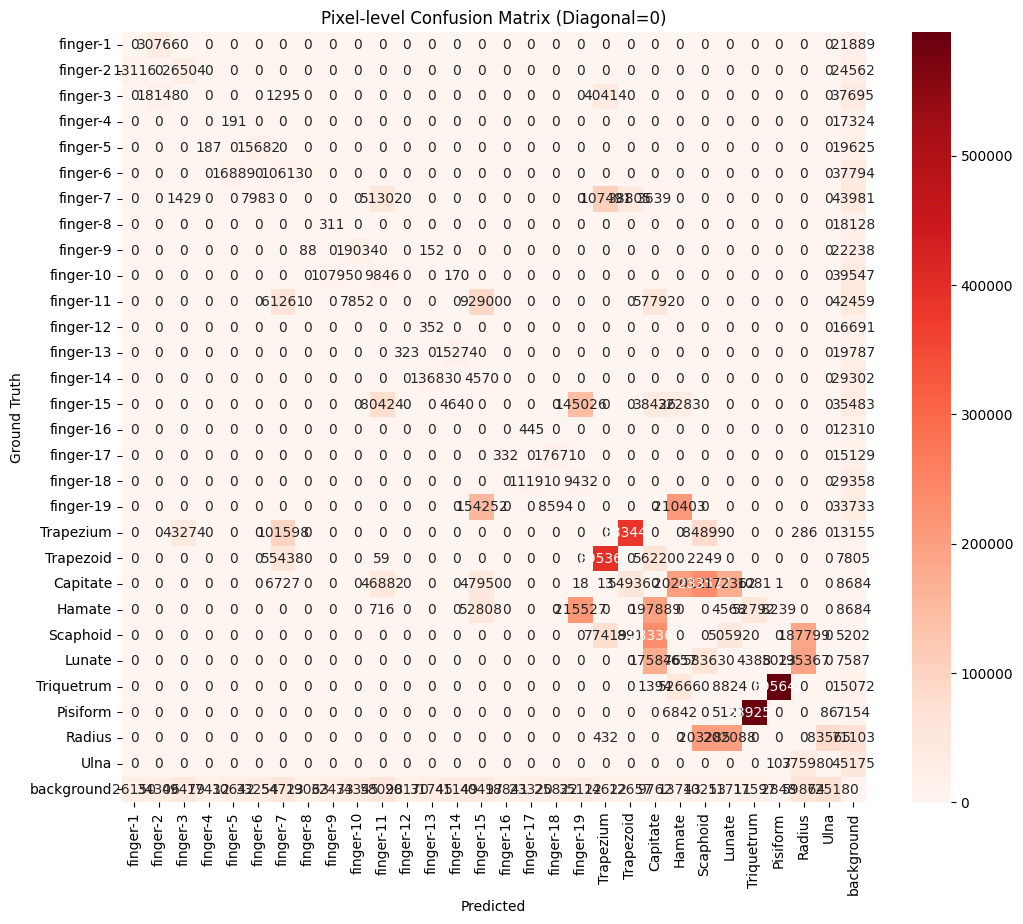

In [21]:
def compute_overall_confusion_matrix(df, cfg, dataset, class2ind, threshold=0.5):
    num_classes = len(class2ind)
    conf_matrix = np.zeros((num_classes + 1, num_classes + 1), dtype=np.int64)  # +1 for background

    for idx in range(len(dataset)):
        _, image_name, gt_label = dataset[idx]
        
        if cfg.tta:
            gt_label = gt_label[0] 

        gt_masks = np.stack([gt_label[i].numpy() for i in range(num_classes)], axis=0)
        gt_masks_bin = (gt_masks > 0).astype(int)

        pred_masks = []
        for class_name, class_idx in class2ind.items():
            rle_row = df[(df['image_name'] == os.path.basename(image_name)) & (df['class'] == class_name)]
            if len(rle_row) == 0:
                pred_mask = np.zeros_like(gt_masks[0])
            else:
                pred_mask = decode_rle_to_mask(rle_row['rle'].values[0], gt_masks.shape[1], gt_masks.shape[2])
            pred_masks.append(pred_mask)
        pred_masks = np.stack(pred_masks, axis=0)
        pred_masks_bin = (pred_masks > threshold).astype(int)

        H, W = gt_masks.shape[1], gt_masks.shape[2]
        for i in range(H):
            for j in range(W):
                gt_pixel_classes = np.where(gt_masks_bin[:, i, j] > 0)[0]
                pred_pixel_classes = np.where(pred_masks_bin[:, i, j] > 0)[0]

                if len(gt_pixel_classes) == 0 and len(pred_pixel_classes) == 0:
                    conf_matrix[-1, -1] += 1  # background -> background
                elif len(gt_pixel_classes) == 0:
                    for p in pred_pixel_classes:
                        conf_matrix[-1, p] += 1  # background -> class
                elif len(pred_pixel_classes) == 0:
                    for g in gt_pixel_classes:
                        conf_matrix[g, -1] += 1  # class -> background
                else:
                    for g in gt_pixel_classes:
                        for p in pred_pixel_classes:
                            conf_matrix[g, p] += 1  # class -> class

    labels = list(class2ind.keys()) + ['background']
    return conf_matrix, labels


def plot_overall_confusion_matrix(cm, labels):
    cm_display = cm.copy()
    for i in range(len(labels)):
        cm_display[i, i] = 0    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_display, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Reds')
    plt.xlabel('Predicted')
    plt.ylabel('Ground Truth')
    plt.title('Pixel-level Confusion Matrix (Diagonal=0)')
    plt.show()


cm, labels = compute_overall_confusion_matrix(df, cfg, valid_dataset, CLASS2IND)
plot_overall_confusion_matrix(cm, labels)

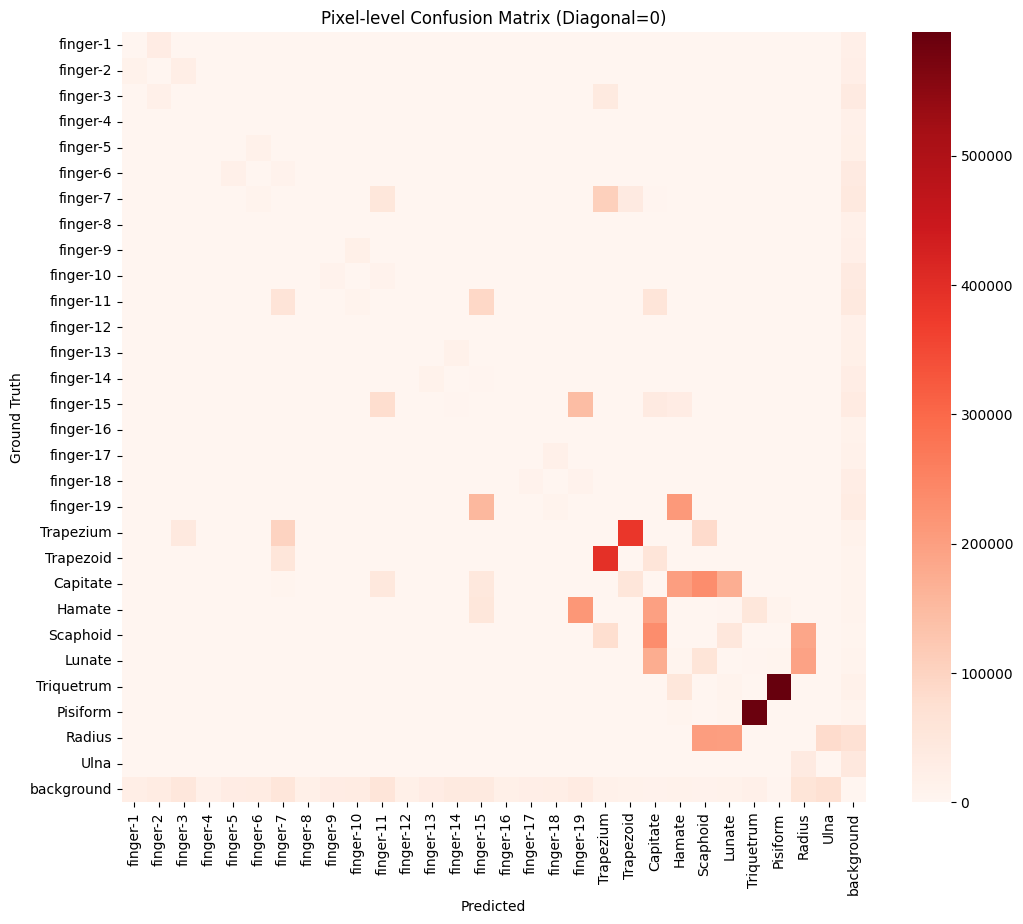

In [22]:
def plot_overall_confusion_matrix(cm, labels):
    cm_display = cm.copy()
    for i in range(len(labels)):
        cm_display[i, i] = 0    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_display, annot=False, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Reds')
    plt.xlabel('Predicted')
    plt.ylabel('Ground Truth')
    plt.title('Pixel-level Confusion Matrix (Diagonal=0)')
    plt.show()

plot_overall_confusion_matrix(cm, labels)

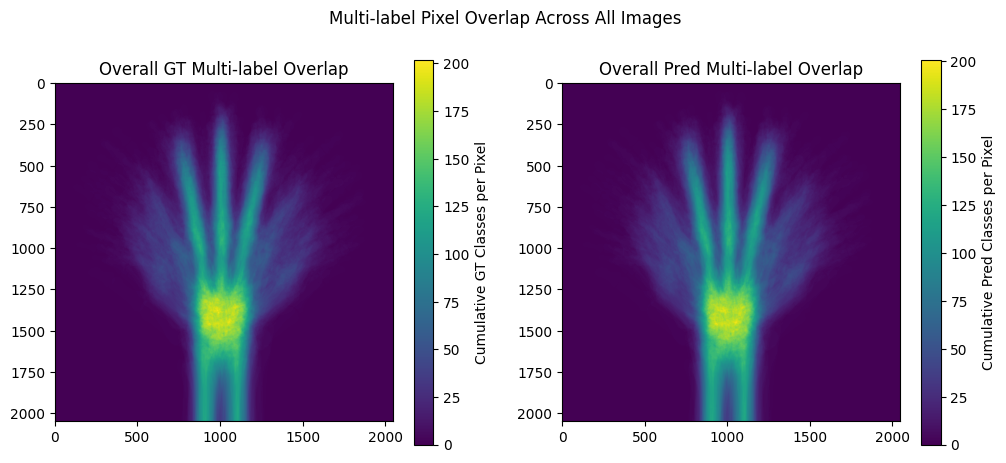

In [23]:
def visualize_multilabel_overlap_all(df, dataset, threshold=0.5):
    num_classes = len(CLASS2IND)
    total_gt_overlap = None
    total_pred_overlap = None

    for idx in range(len(dataset)):
        _, image_name, gt_label = dataset[idx]
        
        if cfg.tta:
            gt_label = gt_label[0] 

        gt_masks = np.stack([gt_label[i].numpy() for i in range(num_classes)], axis=0)
        gt_overlap = np.sum(gt_masks > 0, axis=0)  # 한 픽셀에 몇 클래스 겹치는지

        pred_masks = []
        for class_name, class_idx in CLASS2IND.items():
            rle_row = df[(df['image_name'] == os.path.basename(image_name)) & (df['class'] == class_name)]
            if len(rle_row) == 0:
                pred_mask = np.zeros_like(gt_masks[0])
            else:
                pred_mask = decode_rle_to_mask(rle_row['rle'].values[0], gt_masks.shape[1], gt_masks.shape[2])
            pred_masks.append(pred_mask)

        pred_masks = np.stack(pred_masks, axis=0)
        pred_masks_bin = (pred_masks > threshold).astype(int)
        pred_overlap = np.sum(pred_masks_bin, axis=0)

        if total_gt_overlap is None:
            total_gt_overlap = gt_overlap
            total_pred_overlap = pred_overlap
        else:
            total_gt_overlap += gt_overlap
            total_pred_overlap += pred_overlap

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(total_gt_overlap, cmap='viridis')
    plt.colorbar(label='Cumulative GT Classes per Pixel')
    plt.title('Overall GT Multi-label Overlap')

    plt.subplot(1, 2, 2)
    plt.imshow(total_pred_overlap, cmap='viridis')
    plt.colorbar(label='Cumulative Pred Classes per Pixel')
    plt.title('Overall Pred Multi-label Overlap')

    plt.suptitle('Multi-label Pixel Overlap Across All Images')
    plt.show()

visualize_multilabel_overlap_all(df, valid_dataset, threshold=0.5)

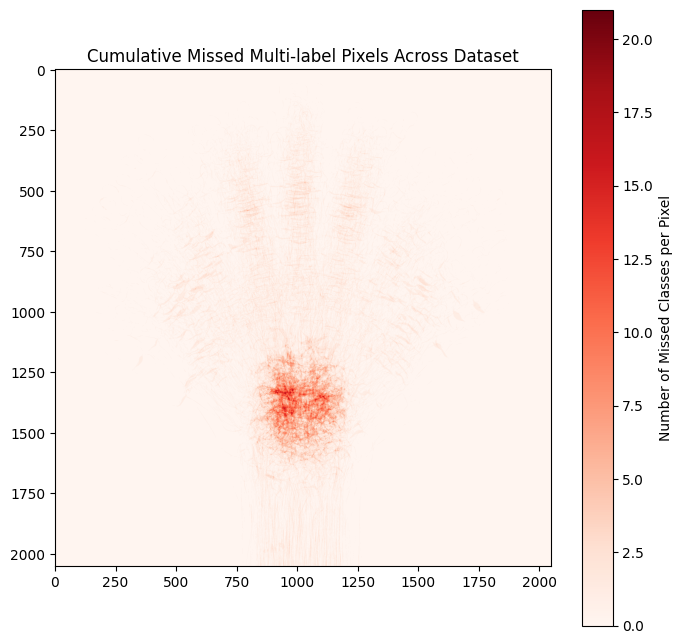

In [24]:
def visualize_missed_multilabel_pixels(df, dataset, threshold=0.5):
    num_classes = len(CLASS2IND)
    missed_overlap_total = None

    for idx in range(len(dataset)):
        _, image_name, gt_label = dataset[idx]

        if cfg.tta:
            gt_label = gt_label[0] 
        
        gt_masks = np.stack([gt_label[i].numpy() for i in range(num_classes)], axis=0)
        gt_overlap = np.sum(gt_masks > 0, axis=0)

        pred_masks = []
        for class_name, class_idx in CLASS2IND.items():
            rle_row = df[(df['image_name'] == os.path.basename(image_name)) & (df['class'] == class_name)]
            if len(rle_row) == 0:
                pred_mask = np.zeros_like(gt_masks[0])
            else:
                pred_mask = decode_rle_to_mask(rle_row['rle'].values[0], gt_masks.shape[1], gt_masks.shape[2])
            pred_masks.append(pred_mask)

        pred_masks = np.stack(pred_masks, axis=0)
        pred_masks_bin = (pred_masks > threshold).astype(int)
        pred_overlap = np.sum(pred_masks_bin, axis=0)

        # 모델이 놓친 멀티레이블 픽셀
        missed_overlap = np.maximum(gt_overlap - pred_overlap, 0)
        if missed_overlap_total is None:
            missed_overlap_total = missed_overlap
        else:
            missed_overlap_total += missed_overlap

    # 시각화
    plt.figure(figsize=(8, 8))
    plt.imshow(missed_overlap_total, cmap='Reds')
    plt.colorbar(label='Number of Missed Classes per Pixel')
    plt.title('Cumulative Missed Multi-label Pixels Across Dataset')
    plt.show()

visualize_missed_multilabel_pixels(df, valid_dataset)

In [25]:
def validation_dice_per_class(model, data_loader, thresholds=[0.5], tta=False):
    model.eval()
    model = model.cuda()
    
    dices_per_class_per_thr = {thr: [] for thr in thresholds}

    with torch.no_grad():
        for images, _, masks in tqdm(data_loader):
            images, masks = images.cuda(), masks.cuda()

            if tta:
                if images.dim() == 4 and images.size(0) % 2 == 0:
                    batch_size = images.size(0) // 2
                    images = images.view(batch_size, 2, images.size(1), images.size(2), images.size(3))
                    masks = masks.view(batch_size, 2, masks.size(1), masks.size(2), masks.size(3))
               
                batch_size, n_tta, C, H, W = images.shape  
                outputs_tta = []
                
                for t in range(n_tta):
                    img = images[:, t]
                    
                    output = model(img)

                    outputs_tta.append(output)
                
                outputs = torch.stack(outputs_tta, dim=1)
                outputs[:, 1] = torch.flip(outputs[:, 1], dims=[-1])
                outputs = torch.mean(outputs, dim=1)
                masks = masks[:, 0]
            else:
                outputs = model(images)
                
            output_h, output_w = outputs.size(-2), outputs.size(-1)
            mask_h, mask_w = masks.size(-2), masks.size(-1)
            
            if output_h != mask_h or output_w != mask_w:
                outputs = F.interpolate(outputs, size=(mask_h, mask_w), mode="bilinear") 

            probs = torch.sigmoid(outputs)

            for thr in thresholds:
                preds = (probs > thr).float()
                dice_batch = dice_coef(masks, preds) 
                dices_per_class_per_thr[thr].append(dice_batch)

    dice_mean_results = {}
    dice_per_class_results = {}
    
    for thr in thresholds:
        dice_class_all = torch.cat(dices_per_class_per_thr[thr], dim=0) 
        dice_per_class_results[thr] = dice_class_all.mean(dim=0).tolist()
        dice_mean_results[thr] = dice_class_all.mean().item()

    return dice_mean_results, dice_per_class_results

In [26]:
set_seed(cfg.seed)
    
model = torch.load(os.path.join(cfg.saved_root, cfg.saved_name), weights_only=False)

valid_dataset = XRayValidDataset(cfg)

valid_loader = DataLoader(
    dataset=valid_dataset, 
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers_val,
    drop_last=False
)

thresholds = torch.linspace(0.1, 0.9, 17).tolist()

dice_mean_results, dice_per_class_results = validation_dice_per_class(model, valid_loader, thresholds=thresholds, tta=cfg.tta)

  0%|          | 0/80 [00:00<?, ?it/s]

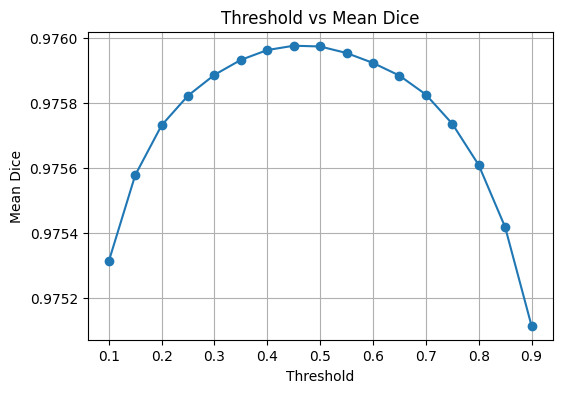

In [27]:
plt.figure(figsize=(6,4))
plt.plot(thresholds, dice_mean_results.values(), marker='o')
plt.xlabel("Threshold")
plt.ylabel("Mean Dice")
plt.title("Threshold vs Mean Dice")
plt.grid(True)
plt.show()

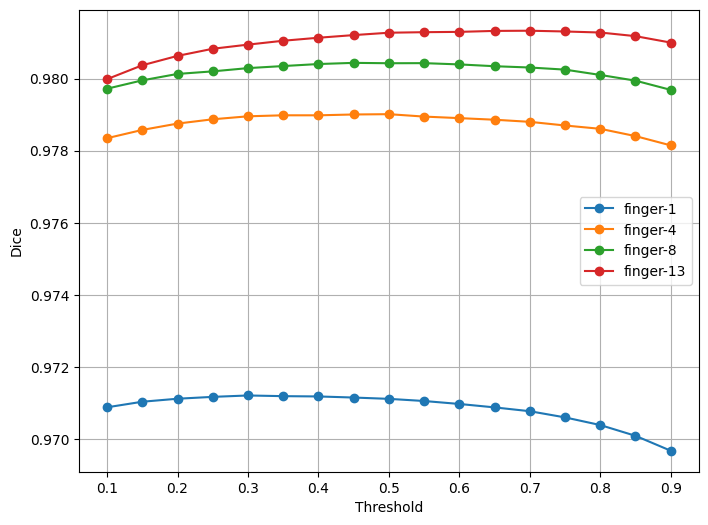

In [36]:
selected_classes = [0, 3, 7, 12]

thresholds = np.array(sorted(dice_per_class_results.keys()))

dice_matrix = np.array([dice_per_class_results[t] for t in thresholds])

plt.figure(figsize=(8,6))
for c in selected_classes:
    plt.plot(
        thresholds,
        dice_matrix[:, c],
        marker='o',
        label=IND2CLASS[c]
    )

plt.xlabel("Threshold")
plt.ylabel("Dice")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
thresholds_list = sorted(dice_per_class_results.keys())
n_classes = len(dice_per_class_results[thresholds_list[0]])

dice_tensor = torch.tensor([dice_per_class_results[thr] for thr in thresholds_list]) 

best_thr_per_class = {}

for c in range(n_classes):
    best_idx = torch.argmax(dice_tensor[:, c])
    best_thr = thresholds_list[best_idx]
    best_dice = dice_tensor[best_idx, c].item()
    
    best_thr_per_class[IND2CLASS[c]] = {
        "best_thr": best_thr,
        "best_dice": best_dice
    }

for class_name in best_thr_per_class:
    print(
        f"class: {class_name} | best threshold: {best_thr_per_class[class_name]['best_thr']:.3f}, "
        f"best dice: {best_thr_per_class[class_name]['best_dice']}"
    )

mean_dice = np.mean([v['best_dice'] for v in best_thr_per_class.values()])
print(f"Validation Dice: {mean_dice}")

class: finger-1 | best threshold: 0.300, best dice: 0.9712051749229431
class: finger-2 | best threshold: 0.450, best dice: 0.9846668243408203
class: finger-3 | best threshold: 0.550, best dice: 0.9883872866630554
class: finger-4 | best threshold: 0.500, best dice: 0.97901451587677
class: finger-5 | best threshold: 0.600, best dice: 0.9787424206733704
class: finger-6 | best threshold: 0.250, best dice: 0.9884748458862305
class: finger-7 | best threshold: 0.500, best dice: 0.9867945909500122
class: finger-8 | best threshold: 0.450, best dice: 0.9804390072822571
class: finger-9 | best threshold: 0.500, best dice: 0.982358455657959
class: finger-10 | best threshold: 0.300, best dice: 0.9895027279853821
class: finger-11 | best threshold: 0.450, best dice: 0.9811840057373047
class: finger-12 | best threshold: 0.700, best dice: 0.9804093241691589
class: finger-13 | best threshold: 0.700, best dice: 0.9813312888145447
class: finger-14 | best threshold: 0.550, best dice: 0.98832768201828
class:

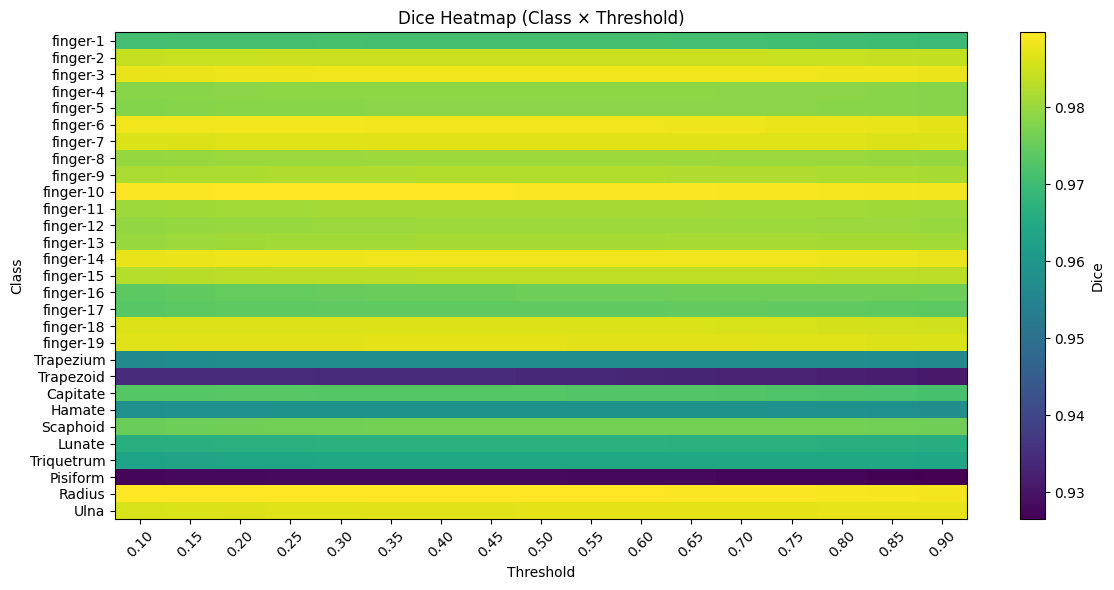

In [ ]:
plt.figure(figsize=(12,6))
plt.imshow(dice_matrix.T, aspect='auto', cmap='viridis')  # transpose: class × threshold
plt.colorbar(label="Dice")

plt.xticks(range(len(thresholds)), [f"{t:.2f}" for t in thresholds], rotation=45)
plt.yticks(range(len(CLASSES)), CLASSES)

plt.xlabel("Threshold")
plt.ylabel("Class")
plt.title("Dice Heatmap (Class × Threshold)")
plt.tight_layout()
plt.show()

In [40]:
class XRayValidDataset(Dataset):         # 전체 데이터 불러오기
    def __init__(self, cfg):
        
        self.image_root = os.path.join(cfg.data_root, "DCM")
        self.label_root = os.path.join(cfg.data_root, "outputs_json")
        
        pngs, jsons = load_HandBonesDataset(self.image_root, self.label_root)
        
        filenames = np.array(pngs)
        labelnames = np.array(jsons)
        
        self.filenames = filenames
        self.labelnames = labelnames
        self.is_train = False
        self.transforms = get_valid_transform(cfg)
        self.tta_transforms = get_tta_transform() if cfg.tta else None
    
    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, item):
        image_name = self.filenames[item]
        image_path = os.path.join(self.image_root, image_name)
        
        image = cv2.imread(image_path)
        image = image / 255.
        
        label_name = self.labelnames[item]
        label_path = os.path.join(self.label_root, label_name)
        
        # (H, W, NC) 모양의 label을 생성합니다.
        label_shape = tuple(image.shape[:2]) + (len(CLASSES), )
        label = np.zeros(label_shape, dtype=np.uint8)
        
        # label 파일을 읽습니다.
        with open(label_path, "r") as f:
            annotations = json.load(f)
        annotations = annotations["annotations"]
        
        # 클래스 별로 처리합니다.
        for ann in annotations:
            c = ann["label"]
            class_ind = CLASS2IND[c]
            points = np.array(ann["points"])
            
            # polygon 포맷을 dense한 mask 포맷으로 바꿉니다.
            class_label = np.zeros(image.shape[:2], dtype=np.uint8)
            cv2.fillPoly(class_label, [points], 1)
            label[..., class_ind] = class_label
        
        if self.transforms is not None:
            inputs = {"image": image, "mask": label} if self.is_train else {"image": image}
            result = self.transforms(**inputs)
            
            image = result["image"]
            label = result["mask"] if self.is_train else label
        
        if self.tta_transforms is not None:
            tta_result = self.tta_transforms(image=image)
            tta_image = tta_result["image"]

            image = np.stack([image, tta_image], axis=0)
            label = np.stack([label, label], axis=0)
        
        if self.tta_transforms is None:
            image = image.transpose(2, 0, 1)
            label = label.transpose(2, 0, 1)
        else:
            image = image.transpose(0, 3, 1, 2)
            label = label.transpose(0, 3, 1, 2)
        
        image = torch.from_numpy(image).float()
        label = torch.from_numpy(label).float()
            
        return image, image_name, label

In [41]:
set_seed(cfg.seed)
    
model = torch.load(os.path.join(cfg.saved_root, cfg.saved_name), weights_only=False)

valid_dataset = XRayValidDataset(cfg)

valid_loader = DataLoader(
    dataset=valid_dataset, 
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers_val,
    drop_last=False
)

dices_per_class, rles, filename_and_class = validation(model, valid_loader, tta=cfg.tta)

classes, filename = zip(*[x.split(",") for x in filename_and_class])
image_name = [os.path.basename(f) for f in filename]
df = pd.DataFrame({
    "image_name": image_name,
    "class": classes,
    "rle": rles,
})

  0%|          | 0/400 [00:00<?, ?it/s]

In [42]:
def dice_per_class(gt, pred, eps=1e-6):
    dices = []
    for c in range(gt.shape[0]):
        g = gt[c].astype(bool)
        p = pred[c].astype(bool)

        inter = np.logical_and(g, p).sum()
        union = g.sum() + p.sum()
        dice = (2 * inter + eps) / (union + eps)
        dices.append(dice)

    return np.array(dices)


def label2rgb(label):
    image_size = label.shape[1:] + (3, )
    image = np.zeros(image_size, dtype=np.uint8)
    
    for i, class_label in enumerate(label):
        image[class_label == 1] = PALETTE[i]
        
    return image


def find_index_by_filename(filename_and_class, target_filename):
    target_filename = target_filename.strip()

    for i, fc in enumerate(filename_and_class):
        _, path = fc.split(",")
        path = path.strip()

        if path == target_filename:
            return i


def decode_json_to_mask(label_path, image_shape):
    with open(label_path, "r") as f:
        annotations = json.load(f)["annotations"]

    mask = np.zeros(image_shape + (len(CLASSES),), dtype=np.uint8)

    for ann in annotations:
        class_name = ann["label"]
        class_idx = CLASS2IND[class_name]
        points = np.array(ann["points"])
        class_mask = np.zeros(image_shape, dtype=np.uint8)
        cv2.fillPoly(class_mask, [points], 1)
        mask[..., class_idx] = class_mask

    # (H, W, C) -> (C, H, W)
    mask = mask.transpose(2, 0, 1)
    return mask


def result_visualization_gt(rles, filename_and_class, index):
    """
    GT vs Prediction 시각화
    """
    fname = filename_and_class[index].split(",")[1].strip()
    
    # GT 불러오기
    label_path = os.path.join(os.path.join(cfg.data_root, "outputs_json"), fname.replace(".png", ".json"))
    image = cv2.imread(os.path.join(os.path.join(cfg.data_root, "DCM"), fname))
    image_shape = image.shape[:2]
    gt_mask = decode_json_to_mask(label_path, image_shape)
    
    # Prediction 불러오기
    preds = []
    image_rles = [rle for rle, f in zip(rles, filename_and_class) if f.endswith(fname)]
    for rle in image_rles:
        pred = decode_rle_to_mask(rle, height=image_shape[0], width=image_shape[1])
        preds.append(pred)
    preds = np.stack(preds, 0)

    # Dice 계산
    dices = dice_per_class(gt_mask, preds)
    mean_dice = dices.mean()

    print(f"[{fname}]")
    print(f"Mean Dice : {mean_dice:.4f}")

    # 시각화
    fig, ax = plt.subplots(1, 2, figsize=(24, 12))
    ax[0].imshow(label2rgb(gt_mask))
    ax[0].set_title("Ground Truth Mask")
    ax[0].axis("off")

    ax[1].imshow(label2rgb(preds))
    ax[1].set_title(f"Predicted Mask\nMean Dice: {mean_dice:.4f}")
    ax[1].axis("off")

    plt.show()

In [ ]:
target_filename = "ID073/image1661736368856.png"
index = find_index_by_filename(filename_and_class, target_filename)

result_visualization_gt(rles, filename_and_class, index)

In [ ]:
target_filename = "ID073/image1661736410568.png"
index = find_index_by_filename(filename_and_class, target_filename)

result_visualization_gt(rles, filename_and_class, index)

In [ ]:
target_filename = "ID363/image1664935962797.png"
index = find_index_by_filename(filename_and_class, target_filename)

result_visualization_gt(rles, filename_and_class, index)

In [ ]:
target_filename = "ID363/image1664935989808.png"
index = find_index_by_filename(filename_and_class, target_filename)

result_visualization_gt(rles, filename_and_class, index)

In [ ]:
target_filename = "ID487/image1666661955150.png"
index = find_index_by_filename(filename_and_class, target_filename)

result_visualization_gt(rles, filename_and_class, index)

In [ ]:
target_filename = "ID487/image1666661971614.png"
index = find_index_by_filename(filename_and_class, target_filename)

result_visualization_gt(rles, filename_and_class, index)